# Curve Fitting Experiment: Parametric Curve Parameter Estimation

This notebook solves the AI/R&D assignment by estimating the unknown parameters of the given parametric curve:

$$
x = t\cos(\theta) - e^{M|t|}\sin(0.3t)\sin(\theta) + X
$$

$$
y = 42 + t\sin(\theta) + e^{M|t|}\sin(0.3t)\cos(\theta)
$$

The unknown parameters are:

- $\theta$: rotation angle
- $M$: exponential growth/decay factor
- $X$: horizontal shift

The goal is to estimate these values using the given `xy_data.csv` points.


## 1. Import Required Libraries

We use:

- `numpy` for numerical calculations
- `pandas` for reading the CSV data
- `matplotlib` for plotting
- `scipy.optimize` for fitting the unknown parameters


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, least_squares

%matplotlib inline


## 2. Define Constants and Parameter Ranges

The assignment gives the following parameter ranges:

- $0^\circ < \theta < 50^\circ$
- $-0.05 < M < 0.05$
- $0 < X < 100$
- $6 < t < 60$

Since Python uses radians in trigonometric functions, we will optimize $\theta$ in degrees for readability and convert it to radians inside the equation.


In [2]:
# Fixed constants from the equation
Y_SHIFT = 42

# Given t range
T_MIN = 6
T_MAX = 60

# Given unknown parameter ranges
THETA_MIN_DEG = 0
THETA_MAX_DEG = 50

M_MIN = -0.05
M_MAX = 0.05

X_MIN = 0
X_MAX = 100

BOUNDS = [
    (THETA_MIN_DEG, THETA_MAX_DEG),
    (M_MIN, M_MAX),
    (X_MIN, X_MAX)
]


## 3. Load the Given CSV Data

The CSV is expected to contain two columns:

- `x`
- `y`

These are the points that lie on the unknown curve.


In [5]:
csv_path = "../xy_data.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError("xy_data.csv not found. Keep it in the same folder as this notebook.")

df = pd.read_csv(csv_path)

print("Shape of data:", df.shape)
print("Columns:", df.columns.tolist())

df.head()


Shape of data: (1500, 2)
Columns: ['x', 'y']


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


In [6]:
# Basic validation
required_columns = {"x", "y"}

if not required_columns.issubset(df.columns):
    raise ValueError("The CSV file must contain columns named 'x' and 'y'.")

x_actual = df["x"].to_numpy(dtype=float)
y_actual = df["y"].to_numpy(dtype=float)

print("Number of points:", len(x_actual))
print("x range:", x_actual.min(), "to", x_actual.max())
print("y range:", y_actual.min(), "to", y_actual.max())


Number of points: 1500
x range: 59.657204 to 109.23152
y range: 46.032295 to 69.68551


## 4. Visualize the Given Points

Before fitting, we plot the given points to understand the shape of the curve.


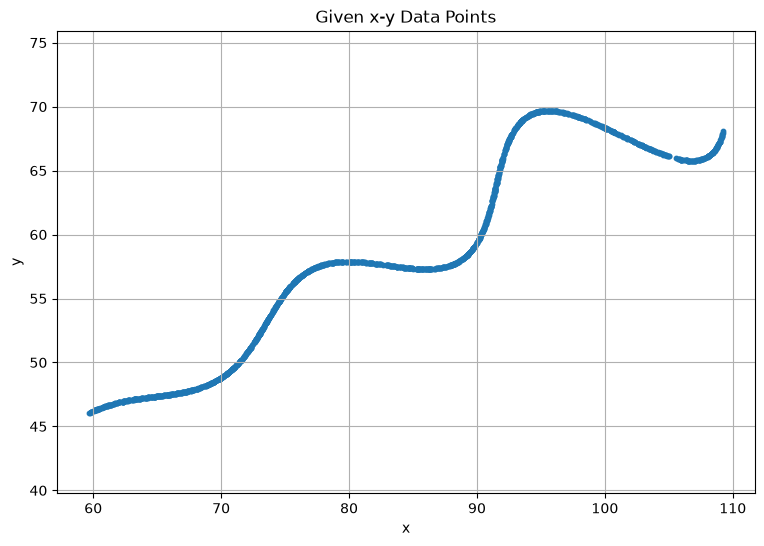

In [7]:
plt.figure(figsize=(9, 6))
plt.scatter(x_actual, y_actual, s=10)
plt.title("Given x-y Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axis("equal")
plt.show()


## 5. Define the Parametric Curve

This function generates predicted `x` and `y` values for given values of:

- $t$
- $\theta$
- $M$
- $X$


In [8]:
def parametric_curve(t, theta_rad, M, X):
    """
    Generate x and y values from the given parametric equation.

    x = t*cos(theta) - e^(M|t|)*sin(0.3t)*sin(theta) + X
    y = 42 + t*sin(theta) + e^(M|t|)*sin(0.3t)*cos(theta)
    """
    wave = np.exp(M * np.abs(t)) * np.sin(0.3 * t)

    x = t * np.cos(theta_rad) - wave * np.sin(theta_rad) + X
    y = Y_SHIFT + t * np.sin(theta_rad) + wave * np.cos(theta_rad)

    return x, y


## 6. Reverse the Transformation

The equation can be understood as a rotated and shifted curve.

If we guess the correct values of $\theta$ and $X$, we can rotate the points back and recover:

$$
u \approx t
$$

$$
v \approx e^{M|t|}\sin(0.3t)
$$

This makes the optimization cleaner because the estimated `u` values behave like the hidden `t` values.


In [9]:
def inverse_transform(x, y, theta_rad, X):
    """
    Reverse the horizontal shift and rotation.

    If theta and X are correct:
    u should be approximately t
    v should be approximately e^(M|t|) * sin(0.3t)
    """
    u = (x - X) * np.cos(theta_rad) + (y - Y_SHIFT) * np.sin(theta_rad)
    v = -(x - X) * np.sin(theta_rad) + (y - Y_SHIFT) * np.cos(theta_rad)

    return u, v


## 7. Define the Error Function

The optimizer will try different values of $\theta$, $M$, and $X$.

For each guess:

1. Convert $\theta$ from degrees to radians.
2. Reverse-transform the actual data points.
3. Treat the recovered `u` as the estimated `t` value.
4. Compare the recovered `v` with the expected wave:

$$
e^{M|u|}\sin(0.3u)
$$

The best parameter values will minimize this difference.


In [10]:
def residuals(params, x_actual, y_actual):
    """
    Residual function for optimization.

    params = [theta_degrees, M, X]
    """
    theta_deg, M, X = params
    theta_rad = np.deg2rad(theta_deg)

    u, v = inverse_transform(x_actual, y_actual, theta_rad, X)

    expected_v = np.exp(M * np.abs(u)) * np.sin(0.3 * u)

    curve_error = v - expected_v

    # Penalty if recovered t/u values go outside the allowed t range.
    lower_penalty = np.maximum(T_MIN - u, 0)
    upper_penalty = np.maximum(u - T_MAX, 0)

    return np.concatenate([
        curve_error,
        10 * lower_penalty,
        10 * upper_penalty
    ])


def objective(params, x_actual, y_actual):
    """
    L1-style objective function.
    Lower value means better fit.
    """
    r = residuals(params, x_actual, y_actual)
    return np.mean(np.abs(r))


## 8. Run Global Optimization

We first use `differential_evolution`, a global optimization method. This helps avoid getting stuck in a bad local solution.

The optimizer searches within the assignment's allowed parameter ranges.


In [11]:
global_result = differential_evolution(
    objective,
    bounds=BOUNDS,
    args=(x_actual, y_actual),
    seed=42,
    tol=1e-10,
    polish=True,
    updating="immediate",
    workers=1
)

print("Global optimization result:")
print("theta_deg, M, X =", global_result.x)
print("objective value =", global_result.fun)


Global optimization result:
theta_deg, M, X = [2.99999730e+01 2.99999971e-02 5.49999983e+01]
objective value = 8.528643704310544e-07


## 9. Refine the Result Using Least Squares

After the global search gives a good starting point, we refine the parameters using `least_squares`.

This gives more precise final values.


In [12]:
refined_result = least_squares(
    residuals,
    global_result.x,
    args=(x_actual, y_actual),
    bounds=(
        [THETA_MIN_DEG, M_MIN, X_MIN],
        [THETA_MAX_DEG, M_MAX, X_MAX]
    ),
    max_nfev=5000,
    xtol=1e-12,
    ftol=1e-12,
    gtol=1e-12
)

theta_deg, M, X = refined_result.x
theta_rad = np.deg2rad(theta_deg)

print("Refined result:")
print(f"theta = {theta_deg:.10f} degrees")
print(f"theta = {theta_rad:.10f} radians")
print(f"M     = {M:.10f}")
print(f"X     = {X:.10f}")


Refined result:
theta = 29.9999729322 degrees
theta = 0.5235983032 radians
M     = 0.0299999969
X     = 54.9999982128


## 10. Calculate Final L1 Error

The assignment mentions L1 distance between the expected and predicted curve.

Here, we calculate a point-wise L1 error after recovering the estimated `t` values using inverse transformation.

$$
L1 = mean(|x_{actual} - x_{predicted}| + |y_{actual} - y_{predicted}|)
$$


In [13]:
def calculate_l1_error(x_actual, y_actual, theta_rad, M, X):
    """
    Calculate point-wise L1 error between actual and predicted points.
    """
    t_estimated, _ = inverse_transform(x_actual, y_actual, theta_rad, X)
    x_predicted, y_predicted = parametric_curve(t_estimated, theta_rad, M, X)

    l1_error = np.mean(
        np.abs(x_actual - x_predicted) + np.abs(y_actual - y_predicted)
    )

    return l1_error


l1_error = calculate_l1_error(x_actual, y_actual, theta_rad, M, X)
print(f"Mean L1 Error: {l1_error:.12f}")


Mean L1 Error: 0.000003496759


## 11. Compare Actual Points and Predicted Curve

Now we generate the predicted curve using the final fitted values and compare it with the original CSV points.


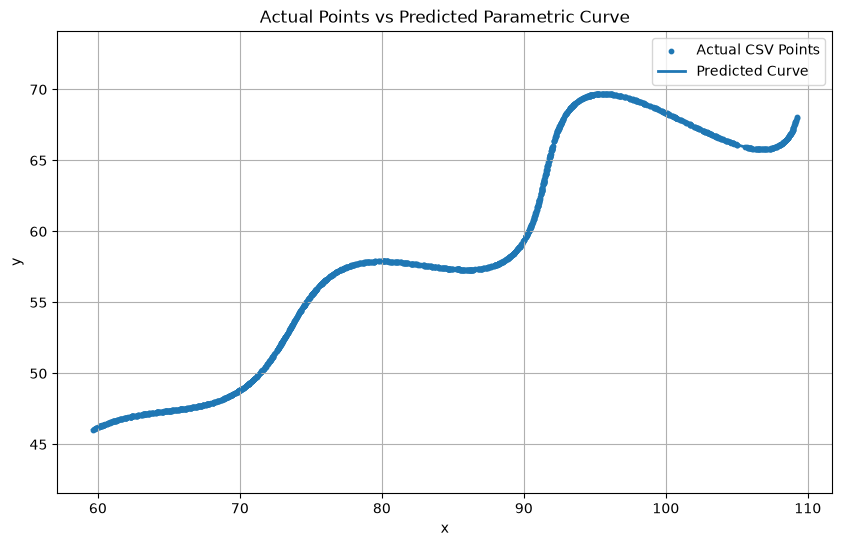

In [14]:
t_values = np.linspace(T_MIN, T_MAX, 1500)
x_predicted, y_predicted = parametric_curve(t_values, theta_rad, M, X)

plt.figure(figsize=(10, 6))
plt.scatter(x_actual, y_actual, s=10, label="Actual CSV Points")
plt.plot(x_predicted, y_predicted, linewidth=2, label="Predicted Curve")
plt.title("Actual Points vs Predicted Parametric Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


## 12. Visualize the Reverse-Transformed Wave

This is an additional verification step.

After applying the inverse transformation with the fitted values, the data should follow:

$$
v = e^{M|u|}\sin(0.3u)
$$

where `u` behaves like `t`.


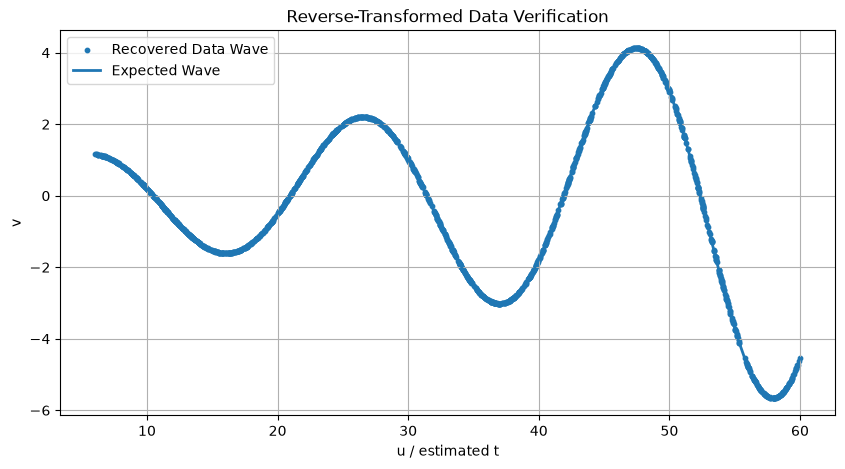

In [15]:
u_estimated, v_estimated = inverse_transform(x_actual, y_actual, theta_rad, X)
v_expected = np.exp(M * np.abs(u_estimated)) * np.sin(0.3 * u_estimated)

sort_idx = np.argsort(u_estimated)

plt.figure(figsize=(10, 5))
plt.scatter(u_estimated, v_estimated, s=10, label="Recovered Data Wave")
plt.plot(u_estimated[sort_idx], v_expected[sort_idx], linewidth=2, label="Expected Wave")
plt.title("Reverse-Transformed Data Verification")
plt.xlabel("u / estimated t")
plt.ylabel("v")
plt.legend()
plt.grid(True)
plt.show()


## 13. Final Parameter Values

The final estimated values are printed below in both degrees and radians.

Radians are used in the final Desmos/Python equation.


In [16]:
print("Final Parameters")
print("----------------")
print(f"theta = {theta_deg:.10f} degrees")
print(f"theta = {theta_rad:.10f} radians")
print(f"M     = {M:.10f}")
print(f"X     = {X:.10f}")
print(f"t range = {T_MIN} to {T_MAX}")
print(f"Mean L1 error = {l1_error:.12f}")


Final Parameters
----------------
theta = 29.9999729322 degrees
theta = 0.5235983032 radians
M     = 0.0299999969
X     = 54.9999982128
t range = 6 to 60
Mean L1 error = 0.000003496759


## 14. Conclusion

The parameter fitting process estimates the curve parameters by minimizing the difference between the provided CSV points and the curve generated from the parametric equation.
